# F3-outgroup statistic for the "Unknown" population (AADR dataset)

This notebook reproduces the R/`admixtools` workflow from the *Example of F3-outgroup-statistic for an Unknown population* slide, adapted to run on **Google Colab**.

It will:
1. Install `conda` on Colab via `condacolab`
2. Install R and the required R packages (`admixtools`, `tidyverse`, `pheatmap`) on the fly
3. Mount your Google Drive and move into the AADR data folder
4. Compute the **F3-outgroup statistic** — `f3(pop1 = Mbuti, pop2 = Unknown, pop3 = <every population>)` — and plot the result

> **Note on runtime:** Step 1 (`condacolab.install()`) automatically **restarts the Colab runtime**. This is expected — after it restarts, just continue running the notebook from the next cell onward (you do not need to re-run the `condacolab.install()` cell itself).

## 1. Install conda (condacolab)

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:07
🔁 Restarting kernel...


The cell above restarts the runtime automatically. Once it has restarted, continue by running the cell below to confirm conda is working, then proceed with the rest of the notebook.

In [1]:
import condacolab
condacolab.check()



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


## 2. Install required R/Python packages

In [2]:
# Core R + dependencies needed by the admixtools R package, via conda-forge
!mamba install -y -c conda-forge \
    r-rlang \
    r-tidyverse \
    r-devtools \
    r-data.table \
    r-rcpp \
    r-rcpparmadillo \
    r-igraph \
    r-matrix \
    r-pgenlibr \
    r-remotes \
    r-tidyverse \
    r-pheatmap \
    r-future \
    r-future.apply \
    r-furrr \
    r-pheatmap


[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   2%
conda-forge/noarch     1%[+] 0.2s
conda-forge/linux-64  15%
conda-forge/noarch    25%[+] 0.3s
conda-forge/linux-64  23%
conda-forge/noarch    42%[+] 0.4s
conda-forge/linux-64  31%
conda-forge/noarch    57%[+] 0.5s
conda-forge/linux-64  39%
conda-forge/noarch    74%[+] 0.6s
conda-forge/linux-64  44%
conda-forge/noarch    85%[+] 0.7s
conda-forge/linux-64  46%
conda-forge/noarch    92%[+] 0.8s
conda-forge/linux-64  49%
conda-forge/noarch    95%conda-forge/noarch                                
[+] 0.9s
conda-forge/linux-64  51%[+] 1.0s
conda-forge/linux-64  58%[+] 1.1s
conda-forge/linux-64  64%[+] 1.2s
conda-forge/linux-64  70%[+] 1.3s
conda-forge/linux-64  75%[+] 1.4s
conda-forge/linux-64  82%[+] 1.5s
conda-forge/linux-64  87%[+] 1.6s
conda-forge/linux-64  91%[+] 1.7s
conda-forge/linux-64  97%conda-forge/linux-64                              

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*c

In [3]:
# in case R magic is not installed
# Uninstall all rpy2-related packages
!pip uninstall rpy2 rpy2-rinterface rpy2-robjects -y

# Install a known-working version
!pip install rpy2==3.5.1


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp313-cp313-linux_x86_64.whl size=248245 sha256=1b27597aa76e59e7bce000c85ced9fd77aeadbf62187eeddd77d135f3f7d4f88
  Stored in directory: /root/.cache/pip/wheels/7e/3a/c3/727f9483ff112acd9f3bdb5e88d902d0f539c1751ce4a24f01
Successfully built rpy2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rpy2]


In [4]:
%load_ext rpy2.ipython

In [5]:
%%R
library(rlang)
packageVersion("rlang")


[1] ‘1.3.0’


In [6]:
%%R
# admixtools (ADMIXTOOLS 2) is not on conda-forge/CRAN, so install it from GitHub
if (!requireNamespace("admixtools", quietly = TRUE)) {
  devtools::install_github("uqrmaie1/admixtools", upgrade = "never")
}

R[write to console]: Downloading GitHub repo uqrmaie1/admixtools@HEAD

R[write to console]: Installing 8 packages: iterators, foreach, quadprog, lobstr, doParallel, data.tree, cubelyr, abind

R[write to console]: Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/foreach_1.5.2.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/quadprog_1.5-8.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/lobstr_1.2.2.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/doParallel_1.0.17.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/data.tree_1.2.0.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/cubelyr_1.0.2.tar.gz'

R[write to console]: t

── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpusDgr6/remotes52b647b7140/uqrmaie1-admixtools-472d04e/DESCRIPTION’ ... OK
* preparing ‘admixtools’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘admixtools_2.0.10.tar.gz’



R[write to console]: Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [7]:
%%R

library("admixtools")
library("tidyverse")
library("pheatmap")

cat("admixtools version:", as.character(packageVersion("admixtools")), "\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()      masks stats::filter()
✖ purrr::flatten()     masks rlang::flatten()
✖ purrr::flatten_chr() masks rlang::flatten_chr()
✖ purrr::flatten_dbl() masks rlang::flatten_dbl()
✖ purrr::flatten_int() masks rlang::flatten_int()
✖ purrr::flatten_lgl() masks rlang::flatten_lgl()
✖ purrr::flatten_raw() masks rlang::flatten_raw()
✖ purrr::invoke()      masks rlang::invoke()
✖ dplyr::lag()         masks stats::lag()
✖ purrr::splice()      masks rlang::splice()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
admixtools version: 2.0.10 


In [8]:
%%R
library(admixtools)
packageVersion("admixtools")

[1] ‘2.0.10’


## 3. Mount Google Drive and move into the AADR folder

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

aadr_dir = '/content/drive/MyDrive/PopGen_PopStructure/AADR'
os.chdir(aadr_dir)
print("Working directory:", os.getcwd())
print(os.listdir('.'))

Working directory: /content/drive/MyDrive/PopGen_PopStructure/AADR
['AADR.geno', 'AADR.ind', 'AADR.snp', 'f2_AADR', 'F3_outgroup.png']


## 4. F3-outgroup statistic for the "Unknown" population

We extract AADR F2-statistics (needed to compute any F-statistic in `admixtools`) and use them to compute an **outgroup F3-statistic**: `f3(pop1 = Mbuti, pop2 = Unknown, pop3 = <every population in the panel>)`.

Using Mbuti as an outgroup, this measures how much shared genetic drift the "Unknown" population has with each other population since their divergence from Mbuti — populations that split more recently from "Unknown" (i.e. are more closely related to it) will have a **higher** F3 value.

Populations are sorted by F3 value and plotted with error bars (±3 standard errors), reproducing the slide's `viz_outgroup_f3()` plot.

> **Tip:** On the full AADR dataset, `extract_f2()` can be slow/memory-heavy. If it's too slow on Colab, restrict to a subset of populations with `extract_f2("AADR", outdir = "f2_AADR", pops = my_pops)`.

In [11]:
%%R

# =============================================================
# F3-outgroup statistic for an Unknown population
# =============================================================

# Load required libraries
library("admixtools")
library("tidyverse")

# 1. Extract F2 statistics from the AADR dataset
#    This computes all pairwise F2 distances and saves them to the "f2_AADR" directory.
# Extract F2 statistics (skips recomputation if already extracted)
if (!dir.exists("f2_AADR")) {
  admixtools::extract_f2("AADR", outdir = "f2_AADR")
}

# 2. Read the F2 data back into R
f2_aadr <- read_f2("f2_AADR")
ind <- read.table("AADR.ind", header = FALSE, stringsAsFactors = FALSE)
colnames(ind) <- c("ID", "sex", "pop")

# 3. Compute Fst from the F2 data
#    (Note: This line is present in the slide but the result `fst_aadr` is not used later in the code)
fst_aadr <- fst(f2_aadr)

# 4. Compute the F3-outgroup statistic
#    pop1 = "Mbuti" (outgroup)
#    pop2 = "Unknown" (target population)
#    pop3 = all other populations in the dataset
f3_aadr <- f3(f2_aadr, pop1 = "Mbuti", pop2 = "Unknown", pop3 = unique(ind$pop)) %>%
  arrange(est)

# 5. Define a custom visualization function for the F3 results
viz_outgroup_f3 <- function(f3_res) {
  f3_res %>%
    mutate(pop3 = fct_reorder(pop3, est)) %>%
    ggplot(aes(x = pop3, y = est, ymin = est - 3 * se, ymax = est + 3 * se)) +
    geom_point() +
    geom_errorbar() +
    coord_flip() +
    theme_bw(15) +
    xlab(NULL) +
    ylab("f3")
}

# 6. Run the visualization
p <- viz_outgroup_f3(f3_aadr)
ggsave("F3_outgroup_AADR.png", plot = p, width = 10, height = 6, units = "in", dpi = 300)

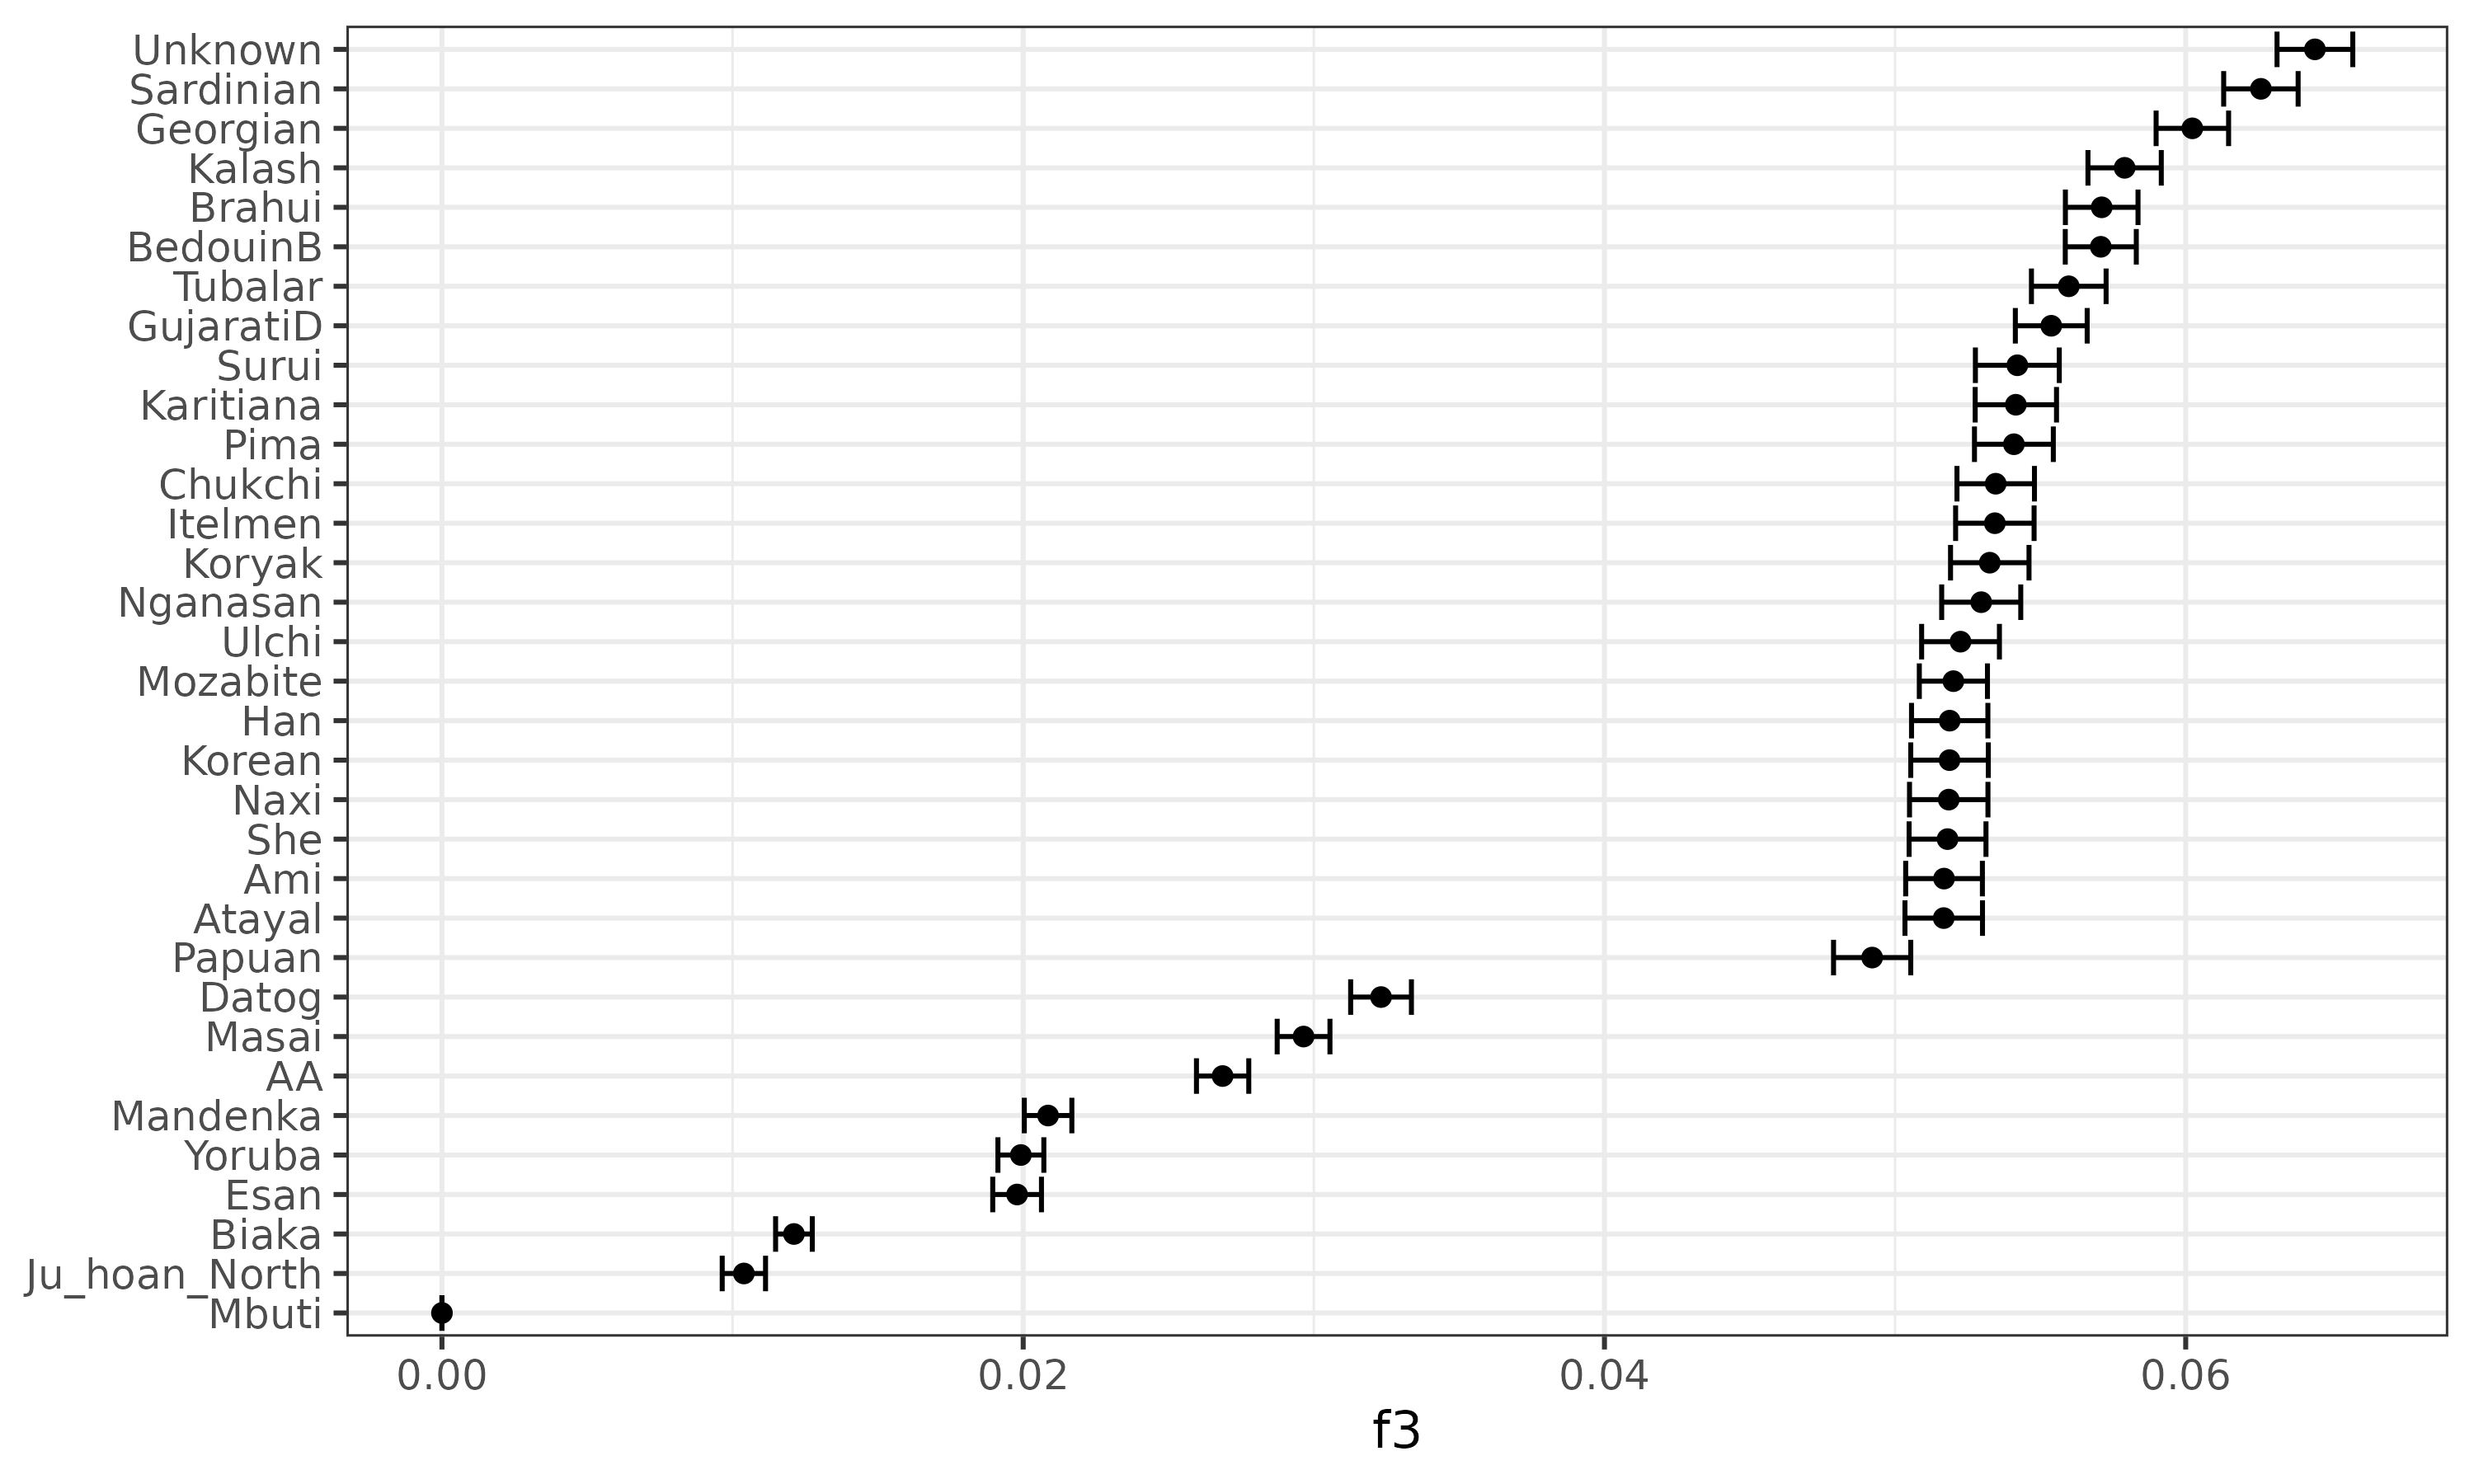

In [12]:
from IPython.display import Image, display
display(Image(filename="F3_outgroup_AADR.png"))

---
### Notes
- `f2_aadr` is recomputed if `f2_AADR` doesn't already exist in the current directory; delete that folder if you ever need to force a fresh extraction.
- `AADR.ind` is assumed to be a standard 3-column EIGENSTRAT individual file (ID, sex, population), with no header row — adjust the `read.table()` call if your file differs.
- The plot is saved to `F3_outgroup.png` in the current working directory (`/content/drive/MyDrive/PopGen_PopStructure/AADR`) before being displayed inline.

As usually, as a final step we will render this notebook to an html-format.

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/PopGen_PopStructure/F3_outgroup_AADR.ipynb